# Проект: Объявления о продаже квартир

## Описание проекта

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

## Загрузка

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
data.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,False,False,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


При первичном анализе было выявлено, что в данных присутствует множество пропущенных значений, которые не содержат информации или отсутствуют для определенных записей.

Для дальнейшей обработки данных необходимо провести анализ и обработку пропущенных значений. Возможные методы работы с пропусками включают замену пропущенных значений, изменение типа данных и использование других методов в зависимости от конкретных особенностей данных.

Таким образом, дальнейшая работа с данными будет включать в себя анализ пропущенных значений и обработку данных для более корректного и надежного анализа и интерпретации результатов исследования.

## Предобработка данных

In [5]:
data['locality_name'] = data['locality_name'].str.replace('поселок', 'посёлок')

In [6]:
list(data['locality_name'])

['Санкт-Петербург',
 'посёлок Шушары',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'городской посёлок Янино-1',
 'посёлок Парголово',
 'Санкт-Петербург',
 'посёлок Мурино',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Ломоносов',
 'Сертолово',
 'Петергоф',
 'Пушкин',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'посёлок Парголово',
 'Санкт-Петербург',
 'деревня Кудрово',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Пушкин',
 'Санкт-Петербург',
 'Коммунар',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Колпино',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'посёлок городского типа Красный Бор',
 'посёлок Мурино',
 'Санкт-Петербург',
 'посёлок Парголово',
 'Санкт-Петербург',
 'Петергоф',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Гатчина',
 'Санкт-Петербург',
 'Санкт-Петербург',
 'Пушкин',
 'Санкт-Петербург',
 'С

In [7]:
data = data.rename(columns={'cityCenters_nearest': 'city_centers_nearest'})

In [8]:
data['first_day_exposition'].value_counts()

first_day_exposition
2018-02-01T00:00:00    368
2017-11-10T00:00:00    240
2017-10-13T00:00:00    124
2017-09-27T00:00:00    111
2018-03-26T00:00:00     97
                      ... 
2018-05-20T00:00:00      1
2015-05-15T00:00:00      1
2015-01-12T00:00:00      1
2015-12-19T00:00:00      1
2015-07-19T00:00:00      1
Name: count, Length: 1491, dtype: int64

In [9]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
data.dtypes

total_images                     int64
last_price                     float64
total_area                     float64
first_day_exposition    datetime64[ns]
rooms                            int64
ceiling_height                 float64
floors_total                   float64
living_area                    float64
floor                            int64
is_apartment                    object
studio                            bool
open_plan                         bool
kitchen_area                   float64
balcony                        float64
locality_name                   object
airports_nearest               float64
city_centers_nearest           float64
parks_around3000               float64
parks_nearest                  float64
ponds_around3000               float64
ponds_nearest                  float64
days_exposition                float64
dtype: object

In [10]:
data['last_price'] = data['last_price'].astype('int')
data['last_price'].describe()

count    2.369900e+04
mean     6.541549e+06
std      1.088701e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.800000e+06
max      7.630000e+08
Name: last_price, dtype: float64

В таблицу добавим новые параметры:
- цена одного квадратного метра;
- день публикации объявления (0 - понедельник, 1 - вторник и т. д.);
- месяц публикации объявления;
- год публикации объявления;
- тип этажа квартиры (значения — «первый», «последний», «другой»).

In [11]:
data['price_per_square_meter'] = data['last_price'] / data['total_area']
data['price_per_square_meter'] = data['price_per_square_meter'].astype('int')

In [12]:
data['weekday_exposition'] = data['first_day_exposition'].dt.weekday

In [13]:
data['month_exposition'] = data['first_day_exposition'].dt.month

In [14]:
data['year_exposition'] = data['first_day_exposition'].dt.year

In [15]:
def floor_category(row):
    floors_total = row['floors_total']
    floor = row['floor']
    if floor == 1:
        return 'первый'
    elif floor == floors_total:
        return 'последний'
    elif 1 < floor < floors_total:
        return 'другой'

data['floor_category'] = data.apply(floor_category, axis = 1)

In [16]:
data['city_centers_nearest_km'] = round(data['city_centers_nearest'] / 1000)

In [17]:
data.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_per_square_meter,weekday_exposition,month_exposition,year_exposition,floor_category,city_centers_nearest_km
0,20,13000000,108.0,2019-03-07,3,2.70,16.0,51.0,8,NaN,False,False,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,120370,3,3,2019,другой,16.0
1,7,3350000,40.4,2018-12-04,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,82920,1,12,2018,первый,19.0
2,10,5196000,56.0,2015-08-20,2,NaN,5.0,34.3,4,NaN,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,92785,3,8,2015,другой,14.0
3,0,64900000,159.0,2015-07-24,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,408176,4,7,2015,другой,7.0
4,2,10000000,100.0,2018-06-19,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,100000,1,6,2018,другой,8.0


## Проведем исследовательский анализ данных

Изучим и опишем параметры:

- общая площадь;
- жилая площадь;
- площадь кухни;
- цена объекта;
- количество комнат;
- высота потолков
- тип этажа квартиры («первый», «последний», «другой»);
- общее количество этажей в доме;
- расстояние до центра города в метрах;
- расстояние до ближайшего парка

In [18]:
Q1 = data['total_area'].quantile(0.25)
Q3 = data['total_area'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_cleaned = data[(data['total_area'] >= lower_bound) & (data['total_area'] <= upper_bound)]

removed_data_percentage = (len(data) - len(data_cleaned)) / len(data) * 100
print(f'Удалено {removed_data_percentage:.2f}% данных')

Удалено 5.23% данных


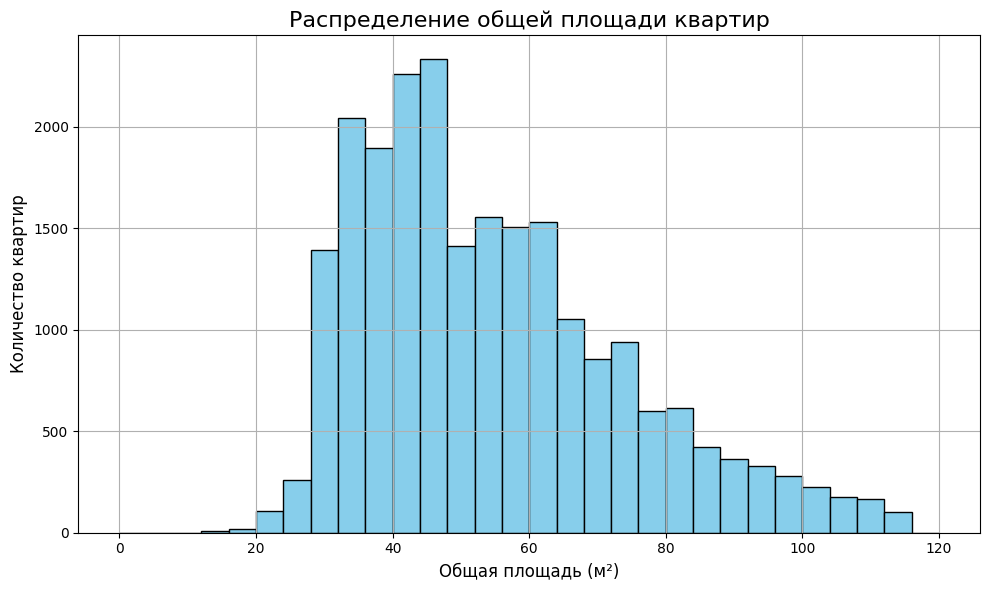

count    22459.000000
mean        54.364907
std         19.385325
min         12.000000
25%         39.400000
50%         50.100000
75%         65.600000
max        114.600000
Name: total_area, dtype: float64

In [19]:
plt.figure(figsize=(10, 6))  
plt.hist(data_cleaned['total_area'], bins=30, range=(0, 120), color='skyblue', edgecolor='black')

plt.title('Распределение общей площади квартир', fontsize=16)
plt.xlabel('Общая площадь (м²)', fontsize=12)
plt.ylabel('Количество квартир', fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

data['total_area'] = data_cleaned['total_area']
data['total_area'].describe()

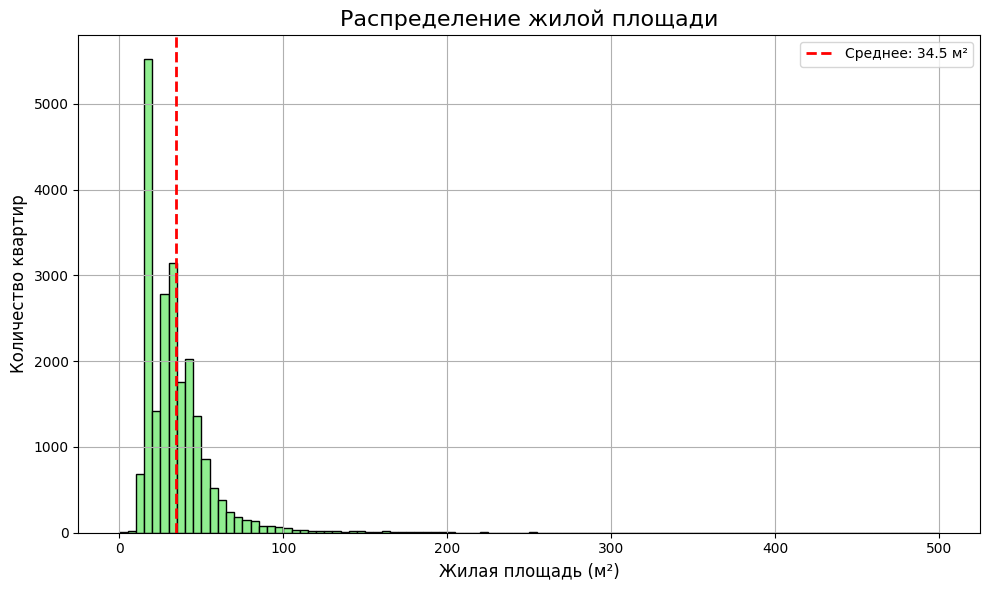

count    21796.000000
mean        34.457852
std         22.030445
min          2.000000
25%         18.600000
50%         30.000000
75%         42.300000
max        409.700000
Name: living_area, dtype: float64

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(data['living_area'], bins=100, range=(0, 500), color='lightgreen', edgecolor='black')

mean_value = data['living_area'].mean()
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {mean_value:.1f} м²')

plt.title('Распределение жилой площади', fontsize=16)
plt.xlabel('Жилая площадь (м²)', fontsize=12)
plt.ylabel('Количество квартир', fontsize=12)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

data['living_area'].describe()

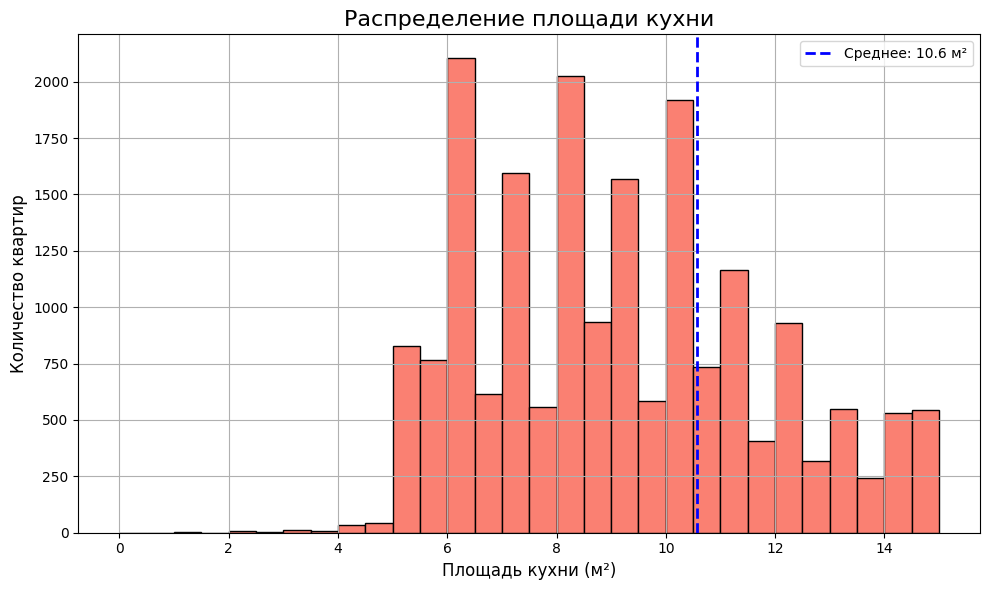

count    21421.000000
mean        10.569807
std          5.905438
min          1.300000
25%          7.000000
50%          9.100000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(data['kitchen_area'], bins=30, range=(0, 15), color='salmon', edgecolor='black')

mean_value = data['kitchen_area'].mean()
plt.axvline(mean_value, color='blue', linestyle='dashed', linewidth=2, label=f'Среднее: {mean_value:.1f} м²')

plt.title('Распределение площади кухни', fontsize=16)
plt.xlabel('Площадь кухни (м²)', fontsize=12)
plt.ylabel('Количество квартир', fontsize=12)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

data['kitchen_area'].describe()

In [22]:
data['last_price'] = data['last_price'].fillna(data['last_price'].median())

Q1, Q3 = data['last_price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
bounds = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

data_cleaned = data[data['last_price'].between(bounds[0], bounds[1])]
removed_pct = 100 * (1 - len(data_cleaned) / len(data))
print(f'Удалено {removed_pct:.2f}% данных')

Удалено 8.58% данных


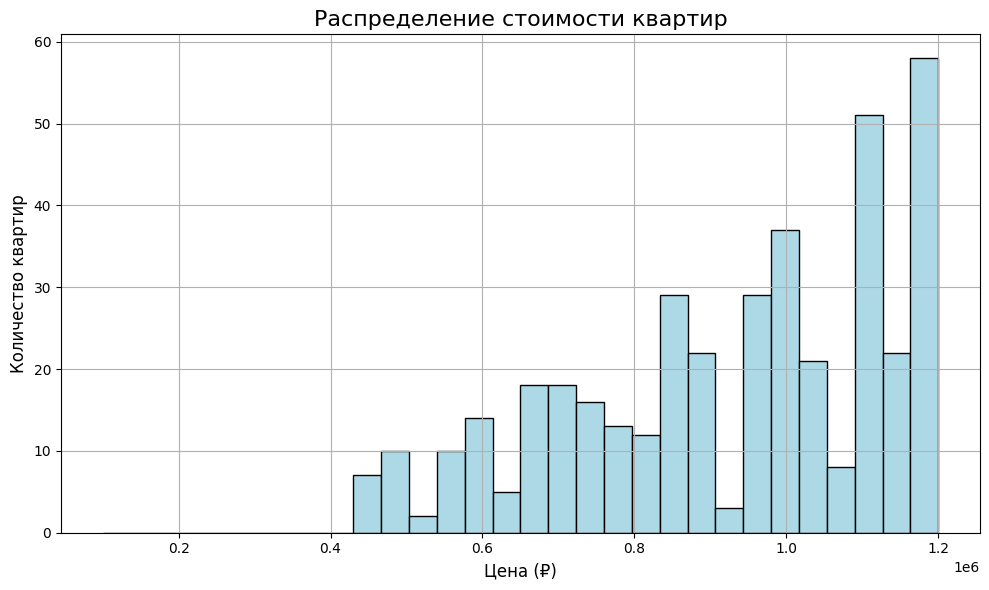

count    2.166500e+04
mean     4.848768e+06
std      2.229914e+06
min      1.219000e+04
25%      3.300000e+06
50%      4.400000e+06
75%      6.000000e+06
max      1.190000e+07
Name: last_price, dtype: float64

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(data_cleaned['last_price'], bins=30, range=(100_000, 1_200_000), color='lightblue', edgecolor='black')
plt.title('Распределение стоимости квартир', fontsize=16)
plt.xlabel('Цена (₽)', fontsize=12)
plt.ylabel('Количество квартир', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

data['last_price'] = data_cleaned['last_price']
data['last_price'].describe()

Удалено 0.38% данных


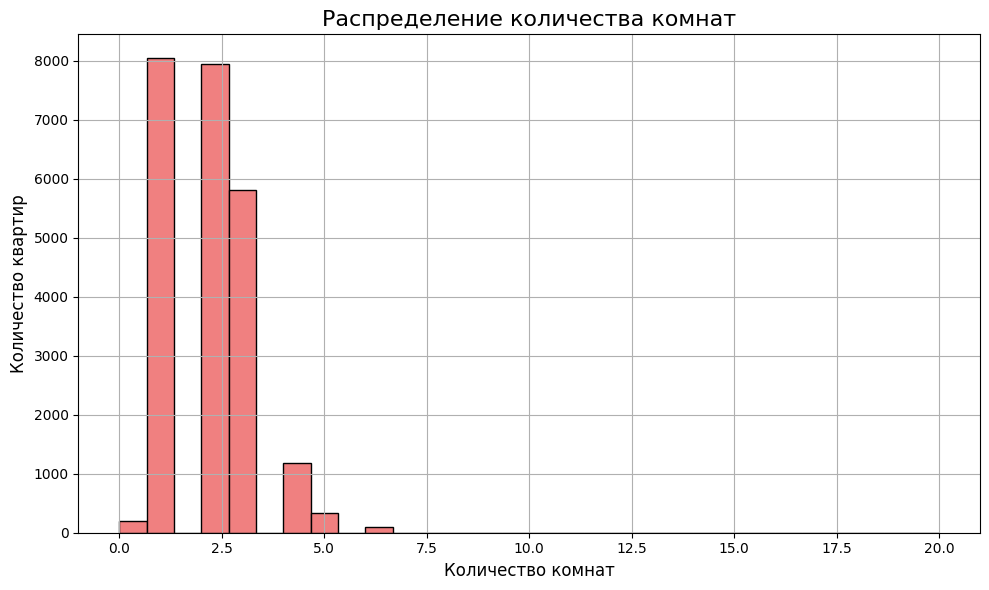

count    23609.000000
mean         2.047905
std          1.006772
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: rooms, dtype: float64

In [54]:
# Очистка выбросов по IQR
Q1, Q3 = data['rooms'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

data_cleaned = data[data['rooms'].between(lower, upper)]

# Подсчёт и вывод доли удалённых данных
removed_pct = 100 * (1 - len(data_cleaned) / len(data))
print(f'Удалено {removed_pct:.2f}% данных')

plt.figure(figsize=(10, 6))
plt.hist(data_cleaned['rooms'], bins=30, range=(0, 20), color='lightcoral', edgecolor='black')
plt.title('Распределение количества комнат', fontsize=16)
plt.xlabel('Количество комнат', fontsize=12)
plt.ylabel('Количество квартир', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Обновление данных и описание
data['rooms'] = data_cleaned['rooms']
data['rooms'].describe()

count      23616
unique         3
top       другой
freq       17363
Name: floor_category, dtype: object

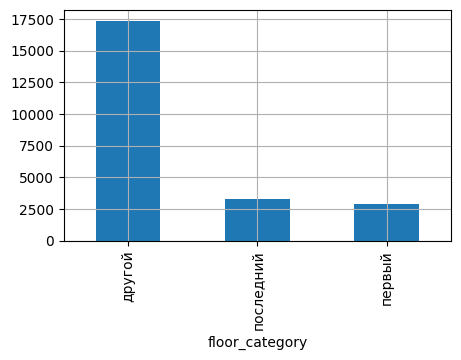

In [27]:
data['floor_category'].value_counts().plot.bar(grid=True, figsize=(5,3))
data['floor_category'].describe()

count    23613.000000
mean        10.673824
std          6.597173
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

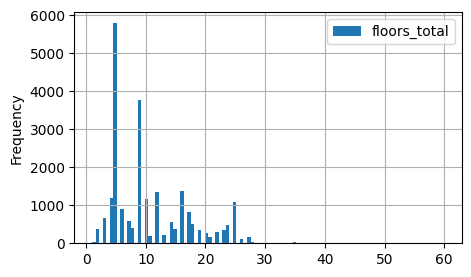

In [28]:
data.plot(y = 'floors_total', kind = 'hist', bins = 100, grid=True, figsize = (5,3))
data['floors_total'].describe()

count    18180.000000
mean     14191.277833
std       8608.386210
min        181.000000
25%       9238.000000
50%      13098.500000
75%      16293.000000
max      65968.000000
Name: city_centers_nearest, dtype: float64

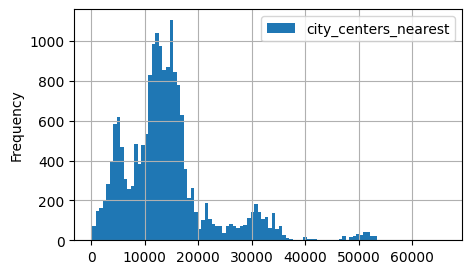

In [29]:
data.plot(y = 'city_centers_nearest', kind = 'hist', bins = 100, grid=True, figsize = (5,3))
data['city_centers_nearest'].describe()

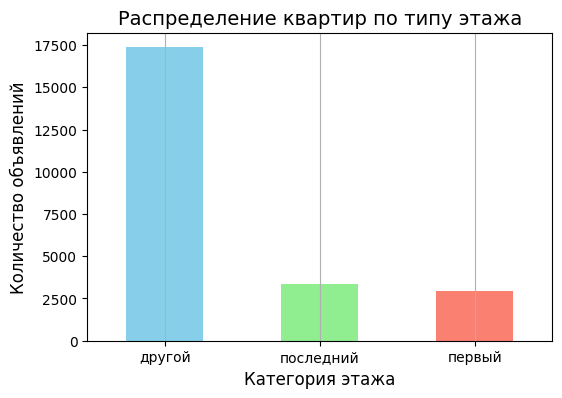

count      23616
unique         3
top       другой
freq       17363
Name: floor_category, dtype: object


In [56]:
data['floor_category'].value_counts().plot.bar(grid=True, figsize=(6,4), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Распределение квартир по типу этажа', fontsize=14)
plt.xlabel('Категория этажа', fontsize=12)
plt.ylabel('Количество объявлений', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

print(data['floor_category'].describe())

In [57]:
selected_columns = ['total_area', 'living_area', 'kitchen_area', 'last_price', 'rooms', 'ceiling_height', 'floors_total', 'city_centers_nearest', 'parks_nearest']
summary_table = data[selected_columns].agg(['median', 'mean'])
summary_table.rename(index={'median': 'Медиана', 'mean': 'Среднее'}, inplace=True)
summary_table

,total_area,living_area,kitchen_area,last_price,rooms,ceiling_height,floors_total,city_centers_nearest,parks_nearest
Медиана,50.100000,30.000000,9.100000,4.400000e+06,2.000000,2.650000,9.000000,13098.500000,455.000000
Среднее,54.364907,34.457852,10.569807,4.848768e+06,2.047905,2.730849,10.673824,14191.277833,490.804555


## Изучите, как быстро продавались квартиры (столбец `days_exposition`)

- построим гистограмму;
- рассчитаем среднее и медиану;
- опишем, сколько обычно занимает продажа и укажем, какие продажи можно считать быстрыми, а какие — необычно долгими.

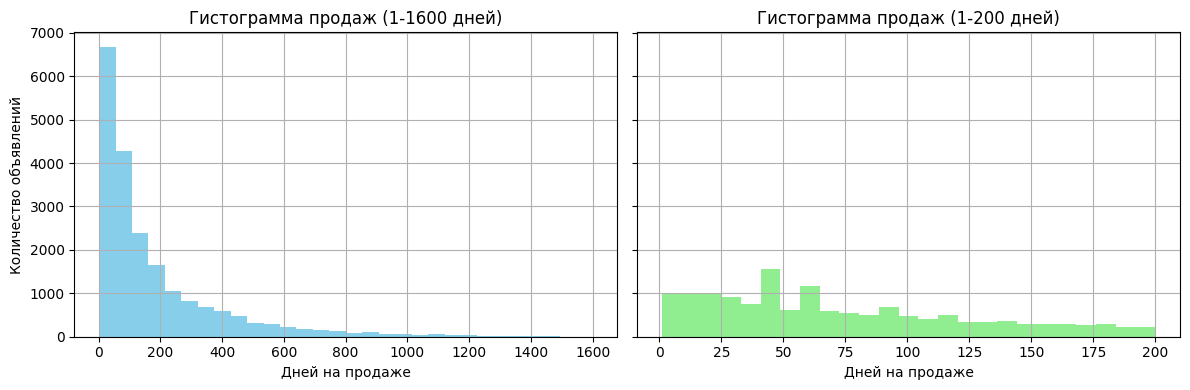

Описание без 0 дней:
 count    20518.000000
mean       180.888634
std        219.727988
min          1.000000
25%         45.000000
50%         95.000000
75%        232.000000
max       1580.000000
Name: days_exposition, dtype: float64

Описание без стандартных значений и 0:
 count    19538.000000
mean       187.906388
std        222.813722
min          1.000000
25%         45.000000
50%        104.000000
75%        244.000000
max       1580.000000
Name: days_exposition, dtype: float64


In [51]:
# Гистограмма по 'days_exposition' с разным масштабом
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

data['days_exposition'].plot(kind='hist', bins=30, grid=True, range=(1,1600), ax=axes[0], color='skyblue')
axes[0].set_title('Гистограмма продаж (1-1600 дней)')
axes[0].set_xlabel('Дней на продаже')
axes[0].set_ylabel('Количество объявлений')

data['days_exposition'].plot(kind='hist', bins=25, grid=True, range=(1,200), ax=axes[1], color='lightgreen')
axes[1].set_title('Гистограмма продаж (1-200 дней)')
axes[1].set_xlabel('Дней на продаже')

plt.tight_layout()
plt.show()

# Описательная статистика без 0 дней
stats_all = data.loc[data['days_exposition'] != 0, 'days_exposition'].describe()
print('Описание без 0 дней:\n', stats_all)

# Исключаем «стандартные» длительности и 0
exclude_days = [0, 7, 30, 45, 60, 90]
good_data = data[~data['days_exposition'].isin(exclude_days)]

stats_good = good_data['days_exposition'].describe()
print('\nОписание без стандартных значений и 0:\n', stats_good)

- В среднем квартира продаётся около 180–188 дней.

- Медианное время продажи — примерно 95–104 дня.

- Значительный разброс — продажи могут длиться от 1 дня до 1580 дней (около 4,3 года).

- Быстрыми можно считать продажи до 1 месяца (30 дней), а продажи дольше 7–8 месяцев (около 240 дней) — уже долгими и редкими.

- Исключение стандартных «типичных» сроков (30, 45, 60 дней и т.п.) немного увеличивает медиану, показывая, что реальная тенденция — чуть более долгие продажи.

## Определите факторы, которые больше всего влияют на общую (полную) стоимость объекта. Постройте графики, которые показывают зависимость цены от параметров:

- общая площадь;
- жилая площадь;
- площадь кухни;
- количество комнат;
- тип этажа, на котором расположена квартира (первый, последний, другой);
- дата размещения (день недели, месяц, год).

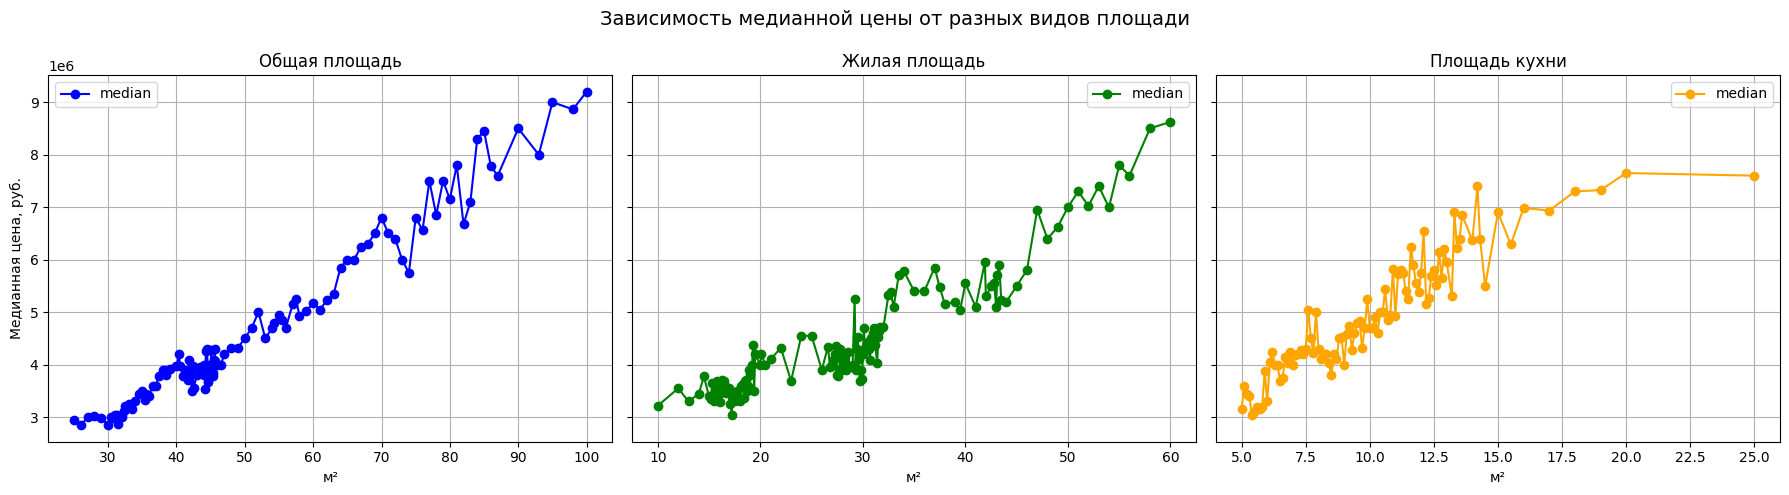

In [34]:
# Создание сводных таблиц
pivot_total = data.pivot_table(index='total_area', values='last_price', aggfunc=['mean', 'count', 'median'])
pivot_living = data.pivot_table(index='living_area', values='last_price', aggfunc=['mean', 'count', 'median'])
pivot_kitchen = data.pivot_table(index='kitchen_area', values='last_price', aggfunc=['mean', 'count', 'median'])

pivot_total.columns = ['mean', 'count', 'median']
pivot_living.columns = ['mean', 'count', 'median']
pivot_kitchen.columns = ['mean', 'count', 'median']

# Фильтрация по количеству наблюдений
pivot_total_filtered = pivot_total.query('count > 30')
pivot_living_filtered = pivot_living.query('count > 30')
pivot_kitchen_filtered = pivot_kitchen.query('count > 30')

# Построение графиков рядом
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Общая площадь
pivot_total_filtered.plot(y='median', style='o-', ax=axes[0], grid=True, color='blue')
axes[0].set_title('Общая площадь')
axes[0].set_xlabel('м²')
axes[0].set_ylabel('Медианная цена, руб.')

# Жилая площадь
pivot_living_filtered.plot(y='median', style='o-', ax=axes[1], grid=True, color='green')
axes[1].set_title('Жилая площадь')
axes[1].set_xlabel('м²')

# Площадь кухни
pivot_kitchen_filtered.plot(y='median', style='o-', ax=axes[2], grid=True, color='orange')
axes[2].set_title('Площадь кухни')
axes[2].set_xlabel('м²')

plt.suptitle('Зависимость медианной цены от разных видов площади', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

1. Общая площадь
📌 Вывод:
Чёткая прямая зависимость — чем больше площадь, тем выше цена. Особенно заметен рост до 70 м². Это важный фактор при оценке недвижимости.

2. Жилая площадь
📌 Вывод:
Связь есть, но слабее, чем с общей площадью. Влияние зависит от планировки — больше жилой площади не всегда значит сильно дороже.

3. Площадь кухни
📌 Вывод:
Явной зависимости нет. Цена мало зависит от кухни — важнее другие параметры, например, расположение или тип жилья.

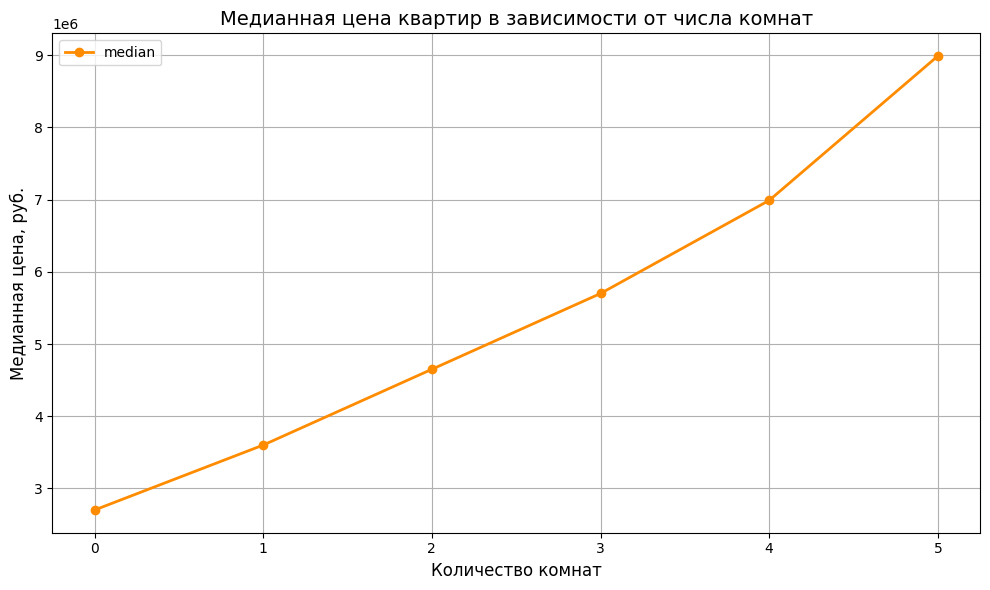

In [37]:
pivot_table_rooms = data.pivot_table(
    index='rooms',
    values='last_price',
    aggfunc=['mean', 'count', 'median']
)
pivot_table_rooms.columns = ['mean', 'count', 'median']

filtered_rooms = pivot_table_rooms.query('count > 50')

filtered_rooms.plot(
    y='median',
    style='o-',
    color='darkorange',
    figsize=(10, 6),
    linewidth=2,
    markersize=6,
    grid=True
)

plt.title('Медианная цена квартир в зависимости от числа комнат', fontsize=14)
plt.xlabel('Количество комнат', fontsize=12)
plt.ylabel('Медианная цена, руб.', fontsize=12)
plt.xticks(filtered_rooms.index)
plt.tight_layout()
plt.show()

Наблюдается прямая зависимость цены от количества комнат.

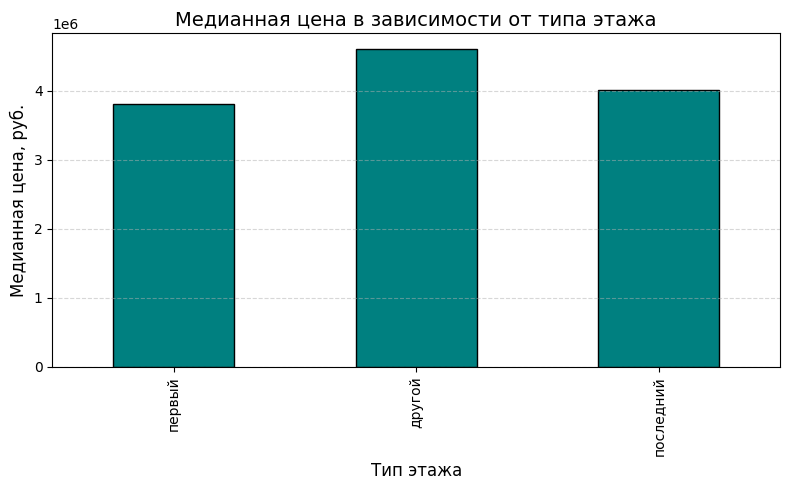

,mean,count,median
floor_category,,,
другой,5.043593e+06,15792,4600000.0
первый,4.126973e+06,2806,3800000.0
последний,4.489907e+06,2996,4003000.0


In [38]:
pivot_table_floor_category = data.pivot_table(
    index='floor_category',
    values='last_price',
    aggfunc=['mean', 'count', 'median']
)
pivot_table_floor_category.columns = ['mean', 'count', 'median']

category_order = ['первый', 'другой', 'последний']

pivot_table_floor_category.loc[category_order].plot(
    y='median',
    kind='bar',
    color='teal',
    figsize=(8, 5),
    legend=False,
    edgecolor='black'
)

plt.title('Медианная цена в зависимости от типа этажа', fontsize=14)
plt.xlabel('Тип этажа', fontsize=12)
plt.ylabel('Медианная цена, руб.', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

pivot_table_floor_category

Квартиры на первом этаже стоят дешевле остальных. Причиной может быть то, что они более подвержены шуму и запахам, а также считаются менее безопасными.

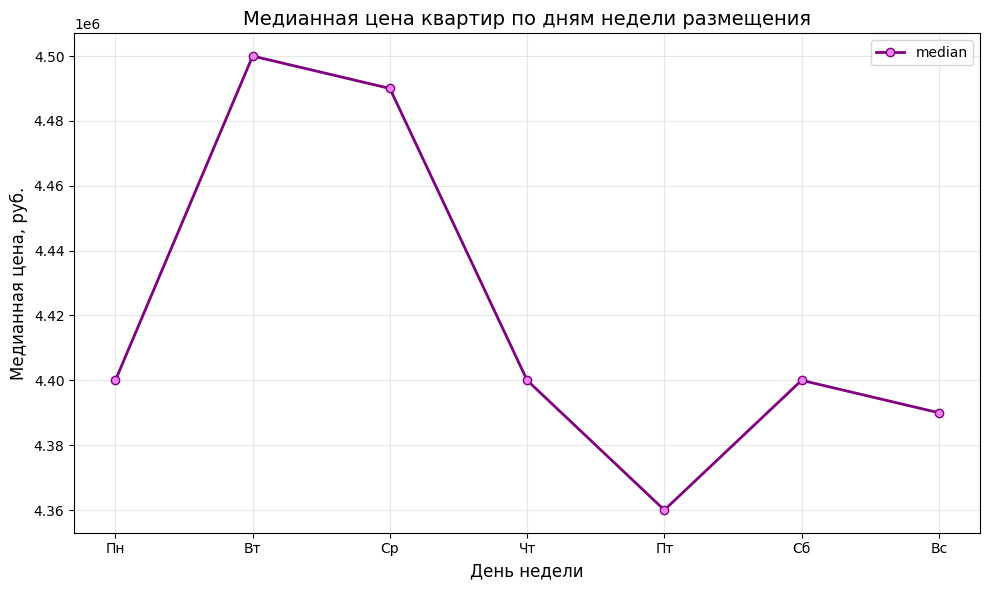

,mean,count,median
weekday_exposition,,,
1,4.905661e+06,3834,4500000.0
2,4.884044e+06,3618,4490000.0
0,4.847435e+06,3299,4400000.0
3,4.856808e+06,3875,4400000.0
5,4.745465e+06,1787,4400000.0
6,4.781053e+06,1570,4390000.0
4,4.826609e+06,3682,4360000.0


In [39]:
pivot_table_weekday_exposition = data.pivot_table(
    index='weekday_exposition',
    values='last_price',
    aggfunc=['mean', 'count', 'median']
)
pivot_table_weekday_exposition.columns = ['mean', 'count', 'median']

weekday_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

pivot_table_weekday_exposition.plot(
    y='median',
    figsize=(10, 6),
    style='o-',
    color='purple',
    linewidth=2,
    markersize=6,
    markerfacecolor='violet',
    grid=True
)

plt.title('Медианная цена квартир по дням недели размещения', fontsize=14)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Медианная цена, руб.', fontsize=12)
plt.xticks(ticks=range(7), labels=weekday_labels)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pivot_table_weekday_exposition.sort_values('median', ascending=False)

Стоимость квартиры, которая предлагается к продаже ближе ко вторнику, имеет в среднем более высокую стоимость. Минимальная стоимость наблюдается по субботам и воскресеньям. Это можно объяснить тем, что в будние дни люди проявляют бо́льшую активность и имеют больше возможностей и желания осуществлять сделки, что оказывает влияние на цены.


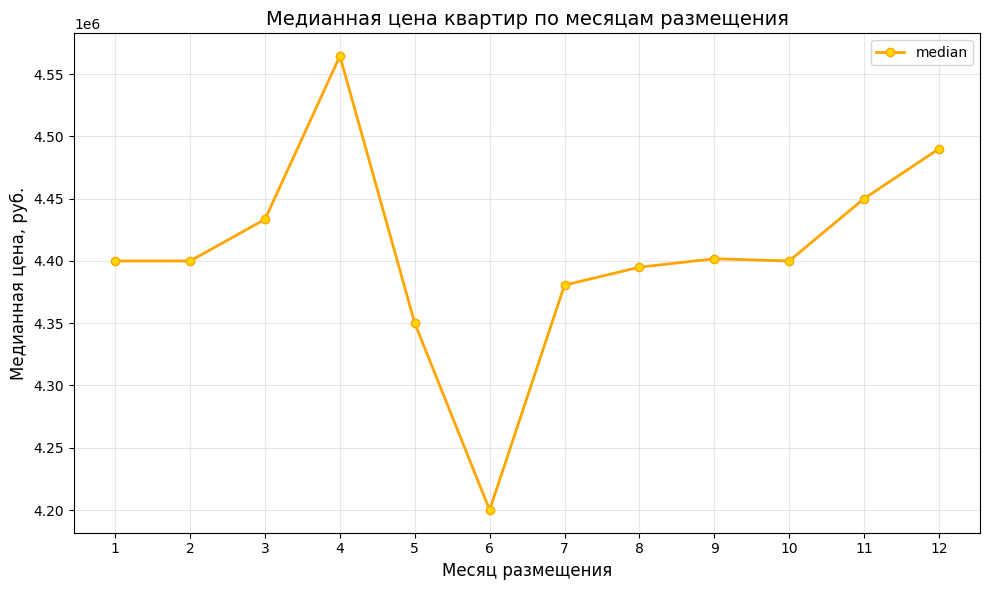

,mean,count,median
month_exposition,,,
4,4.953743e+06,2182,4564580.0
12,4.862257e+06,1497,4490000.0
11,4.866079e+06,2153,4450000.0
3,4.809579e+06,2369,4433484.0
9,4.956280e+06,1804,4401770.5
1,4.801527e+06,1357,4400000.0
2,4.845414e+06,2417,4400000.0
10,4.821700e+06,1959,4400000.0
8,4.859378e+06,1601,4395000.0


In [40]:
pivot_table_month_exposition = data.pivot_table(
    index='month_exposition',
    values='last_price',
    aggfunc=['mean', 'count', 'median']
)
pivot_table_month_exposition.columns = ['mean', 'count', 'median']

pivot_table_month_exposition.plot(
    y='median',
    figsize=(10, 6),
    style='o-',
    color='orange',
    linewidth=2,
    markersize=6,
    markerfacecolor='gold',
    grid=True
)

plt.title('Медианная цена квартир по месяцам размещения', fontsize=14)
plt.xlabel('Месяц размещения', fontsize=12)
plt.ylabel('Медианная цена, руб.', fontsize=12)
plt.xticks(ticks=range(1, 13))  # месяцы от 1 до 12
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pivot_table_month_exposition.sort_values('median', ascending=False)

Пик стоимости квартир приходится на апрель и сентябрь, минимальные значения приходятся на май и июнь.

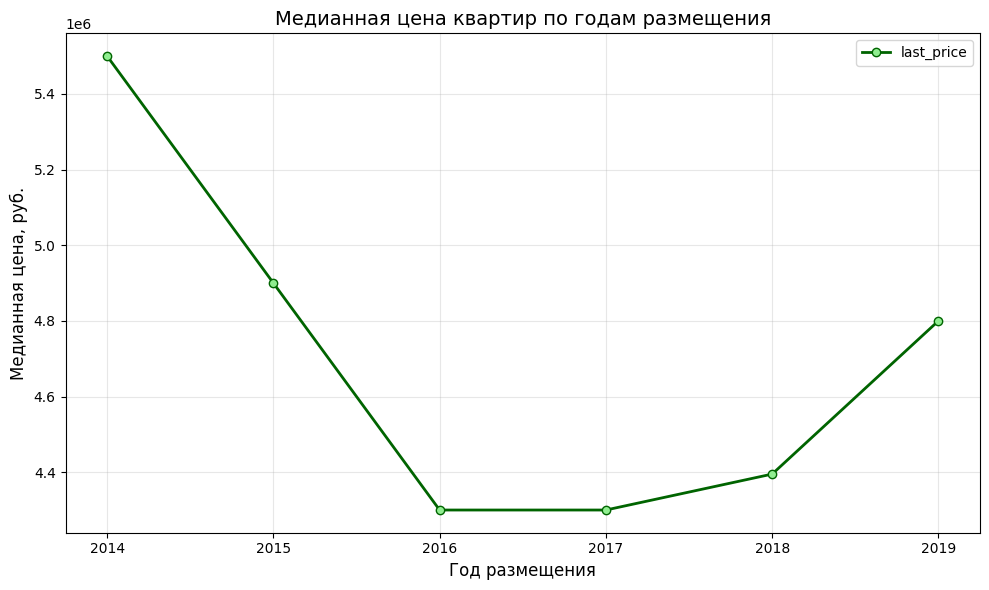

In [55]:
pivot_table_year_exposition = data.pivot_table(index = 'year_exposition', values = 'last_price', aggfunc = ['mean', 'count', 'median'])


pivot_table_year_exposition.plot(
    y='median',
    figsize=(10, 6),
    style='o-',
    color='darkgreen',
    linewidth=2,
    markersize=6,
    markerfacecolor='lightgreen',
    grid=True
)

plt.title('Медианная цена квартир по годам размещения', fontsize=14)
plt.xlabel('Год размещения', fontsize=12)
plt.ylabel('Медианная цена, руб.', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Данные показывают, что с 2014 по 2016 год наблюдался спад цен на недвижимость, однако с 2017 года начался рост стоимости. Это может объясняться различными факторами, такими как [экономическая ситуация в стране](https://translated.turbopages.org/proxy_u/en-ru.ru.92a76fc1-65f2ea6a-76d0e3bc-74722d776562/https/en.wikipedia.org/wiki/Russian_financial_crisis_(2014–2016)), уровень инфляции, изменение процентных ставок по ипотечным кредитам и общая динамика рынка недвижимости.

Кроме того, необходимо учитывать сегментацию рынка недвижимости и индивидуальные особенности каждого объекта. Один и тот же тип недвижимости может вести себя по-разному в зависимости от года, местоположения, состояния здания и других факторов.

Однако для более точных выводов необходимо проводить дополнительные исследования с учетом различных факторов и особенностей каждого объекта недвижимости.

## Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений
- выделим населённые пункты с самой высокой и низкой стоимостью квадратного метра.

In [ ]:
locality_pivot_table = data.pivot_table(index = 'locality_name', values = 'price_per_square_meter', aggfunc=['count', 'mean'])
locality_pivot_table.columns = ['count', 'mean']
locality_pivot_table = locality_pivot_table.sort_values('count', ascending = False).head(10)
locality_pivot_table

locality_pivot_table.head(10)

Самое дорогое жилье среди населенных пунктов с наибольшим количеством объявлений в Санкт-Петербурге, а самое дешевое - в Выборге.

## Выделите квартиры в Санкт-Петербурге с помощью столбца `locality_name` и вычислите их среднюю стоимость на разном удалении от центра
-  учтём каждый километр расстояния, найдем средние цены квартир в одном километре от центра, в двух и так далее;
-  опишем, как стоимость объекта зависит от расстояния до центра города;
-  построим график изменения средней цены для каждого километра от центра Петербурга.

In [ ]:
data.query('locality_name == "Санкт-Петербург"')['city_centers_nearest_km'].describe()

In [ ]:
(
    data.query('locality_name == "Санкт-Петербург"')
    .pivot_table(index='city_centers_nearest_km', values='last_price')
    .plot(
        figsize=(10, 6),
        style='o-',
        color='darkblue',
        markerfacecolor='skyblue',
        markersize=6,
        linewidth=2,
        grid=True,
        xlim=(0, 15)
    )
)

plt.title('Зависимость средней цены от расстояния до центра СПб', fontsize=14)
plt.xlabel('Расстояние до центра (км)', fontsize=12)
plt.ylabel('Средняя цена, руб.', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Наблюдается прямая корреляция стоимости жилья с удаленностью от центра. По мере увеличения расстояния от центра стоимость жилья снижается. <u>Исходя из графика, мы видим, что радиуса от центра Санкт-Петербурга составляет примерно 7 км.</u>

## Общий вывод

Мы провели предварительную обработку данных, в процессе которой мы заполнили пропущенные значения там, где это было возможно, описали обнаруженные пропущенные значения, установили корректные типы данных для каждого столбца, устранили неявные дубликаты, обработали редкие и аномальные значения, добавили новые параметры в таблицу, изучили и описали характеристики квартир, а также исследовали скорость продажи квартир. Мы также определили факторы, которые в наибольшей степени влияют на общую стоимость объектов, рассчитали среднюю стоимость одного квадратного метра жилой площади в десяти городах и вычислили среднюю стоимость квартир в Санкт-Петербурге в зависимости от удаленности от центра города.

Средний срок продажи квартир в рассмотренных городах составляет около полугода со средним значением 196 дней. Однако медианное значение ближе к 4 месяцам (114 дней), что говорит о наличии довольно большого разброса по срокам продажи. Максимальная длительность продажи, зафиксированная в данном исследовании, превышает 4 года и составляет 1580 дней. Минимальная длительность продажи всего один день.

В ходе исследования была выявлена прямая зависимость между стоимостью квартир и их характеристиками. Было установлено, что цена квартиры прямо коррелирует с ее общей площадью и количеством комнат. Это означает, что квартиры с большей площадью или большим количеством комнат стоят дороже.

Также была выявлена зависимость стоимости жилья от его расположения относительно центра города. В рассмотренном городе было отмечено, что стоимость жилья снижается по мере увеличения расстояния от центра города. Это может быть связано с различными факторами, включая доступность общественного транспорта, уровень инфраструктуры и престижность района.

Кроме того, были определены месяцы с максимальными и минимальными значениями стоимости квадратного метра жилья. Пик стоимости приходится на апрель и сентябрь, а минимальные значения приходятся на май и июнь.